### This jupyter notebook contains contents of the lesson "Regularization in Linear models"

**Author : Umidjon Sattorov. Machine Learning engineer**

In [145]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Yuqoridagi jadvalda MohirDev MChJ tomonidan turli OAV larda (`TV`, `Radio`, `Newspaper`) berilgan reklamalar soni va mos keluvchi savdolar (`Sales`) berilgan.

Sizning vazifangiz:
1. Aynan qaysi turdagi OAVda reklama berish savdo o'sishiga ta'sir qiladi aniqlash
2. Topilgan bog'liqlik asosida Simple Linear Regression algorithmi yordamida bashorat modelini qurish.

Linear regression modeli uchun faqat bitta ustunni tanlab oling.

In [171]:
# Loading dataframe
df = pd.read_csv('sales_report.csv')
df.drop(columns = ['Unnamed: 0'], inplace = True)
df.head(20)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


In [147]:
df.drop(columns=['Radio', 'Newspaper'], inplace=True)

In [172]:
# Checking Nan information from the dataset
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [149]:
df.corr()

,TV,Sales
TV,1.000000,0.901208
Sales,0.901208,1.000000


In [150]:
import random
sales = [random.randrange(0, 50) for i in range(10)]
Tv = [random.randrange(70, 80) for i in range(10)]

In [151]:
df_anomal = pd.DataFrame({'TV': sales, 'Sales': Tv})
df_anomal

,TV,Sales
0,22,73
1,1,72
2,19,78
3,16,70
4,14,74
5,19,70
6,37,71
7,10,74
8,25,70
9,25,72


In [152]:
df = pd.concat([df, df_anomal], axis=0)
df.reset_index(inplace=True)

In [153]:
df.drop(columns=['index'], inplace=True)

In [177]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X = df[['TV', 'Radio', 'Newspaper']], y = df['Sales'])
result = lr.predict(X = df[['TV', 'Radio', 'Newspaper']])

result

array([21.22097209, 11.26824775, 10.49620897, 17.31244651, 15.64413685,
       10.35633677, 11.2732847 , 13.27062458,  5.31839603, 15.78871013,
        8.8527202 , 18.88400523,  9.69879662, 10.74921373, 19.27328852,
       20.38554445, 12.27105794, 24.20214502, 10.5924398 , 15.20872794,
       19.49794066, 18.10414656,  7.06177654, 18.87221072,  9.37145421,
       19.31996936, 15.54479137, 19.49216302, 21.07865408, 10.19471067,
       23.61492832, 12.64683045, 10.08782551, 21.2260486 ,  9.98787085,
       20.89407055, 23.84503494, 13.99342411,  9.8404516 , 21.08344935,
       18.04712878, 17.84885818, 23.57494339, 16.79762772,  8.75617872,
       16.57668108, 10.58020572, 22.13342743, 18.70257411,  9.53181337,
       15.84670856, 11.11990058, 20.88243422, 19.53008343, 22.01500291,
       20.76038994,  8.04320903, 14.10063486, 21.4222098 , 19.25650785,
        7.75915886, 23.43911942, 19.32168181, 13.3867616 , 16.35231896,
        9.37729644,  8.97313482, 13.7643628 , 20.49677834, 21.13

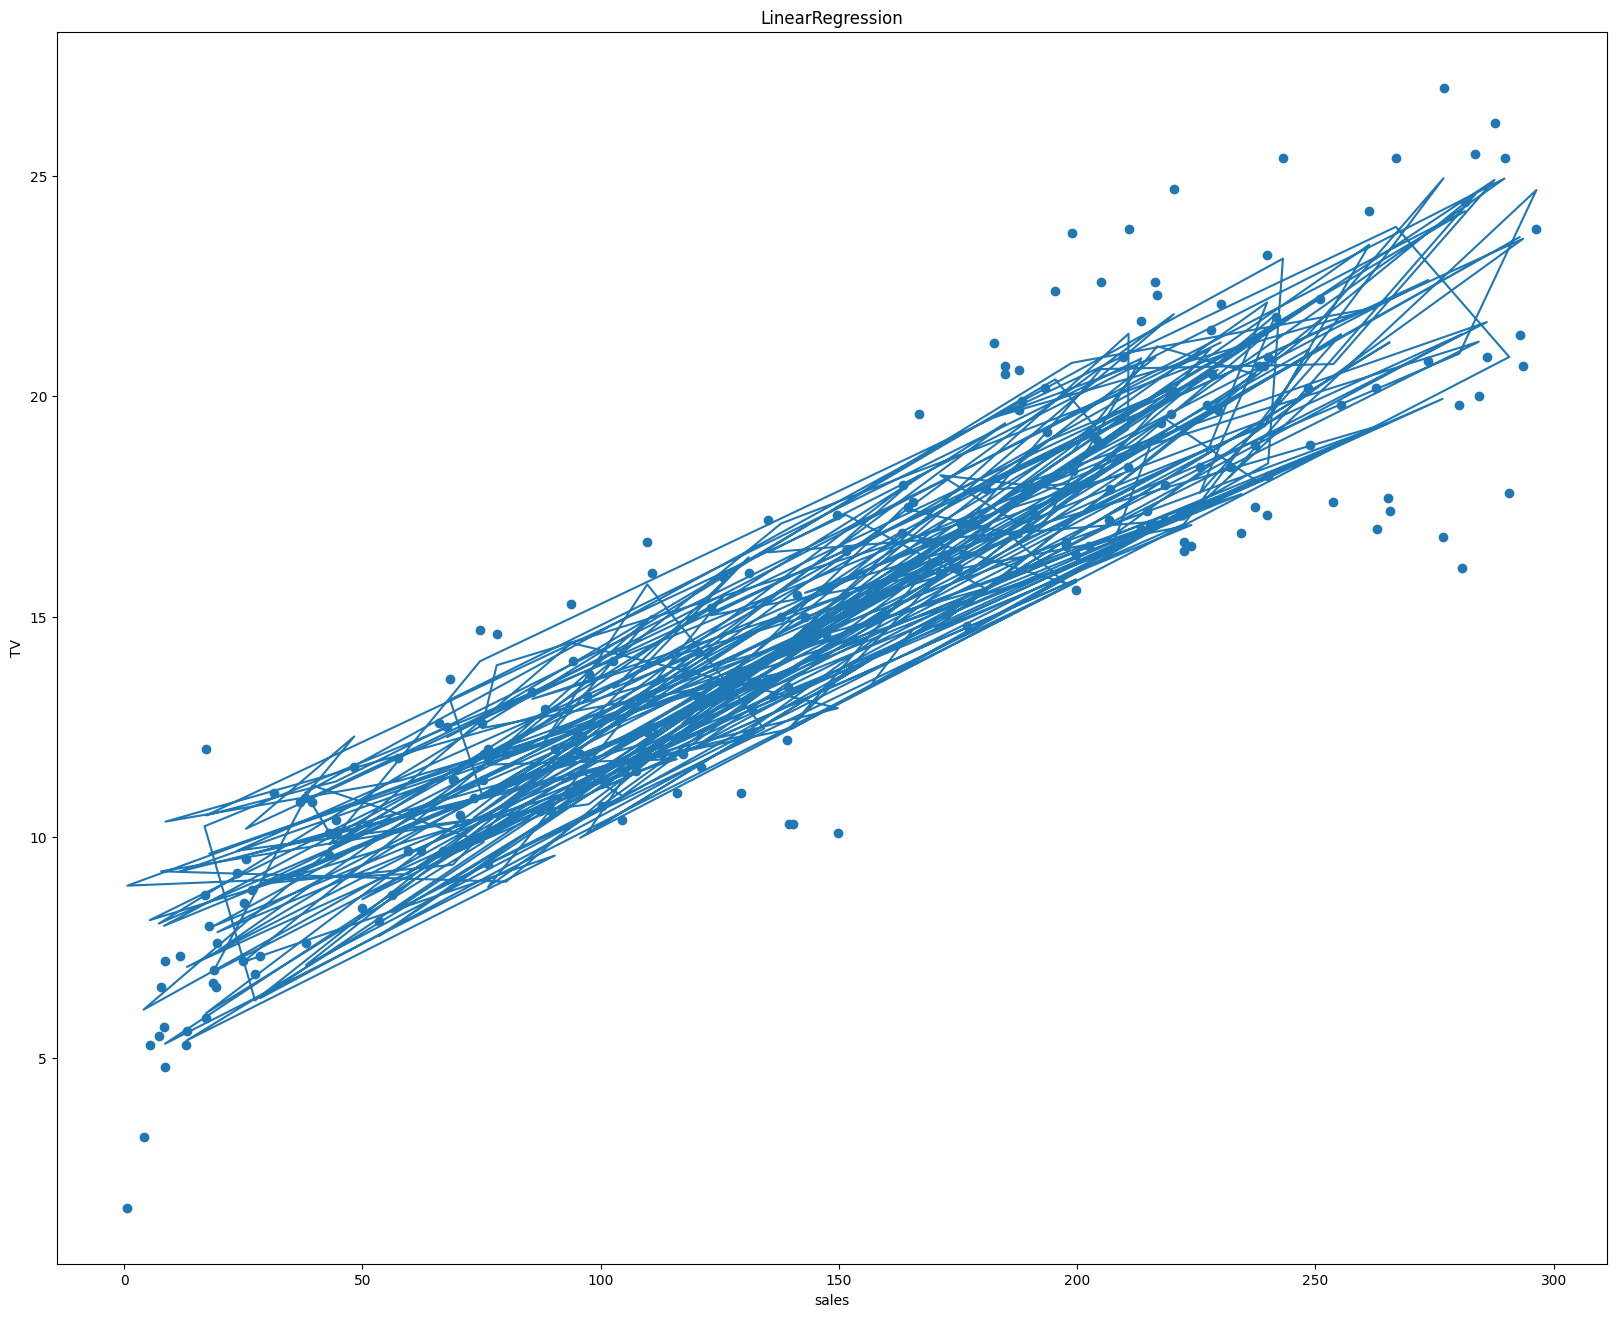

In [178]:
plt.figure(figsize=(20, 16))
plt.title('LinearRegression')
plt.scatter(x = df['TV'], y = df['Sales'])
plt.plot(df['TV'], result)
plt.xlabel(xlabel='sales')
plt.ylabel(ylabel='TV')
plt.show()

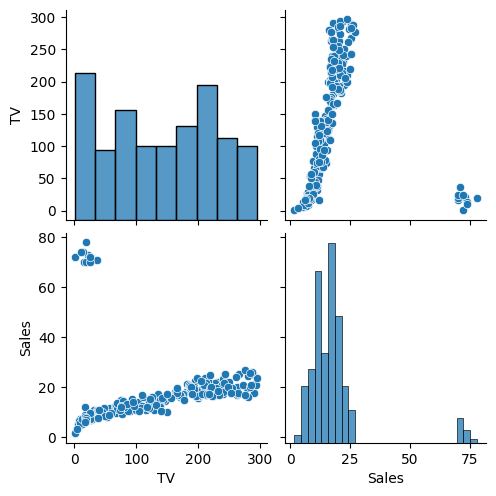

In [156]:
sns.pairplot(df)

In [179]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mean_absolute_error(y_true=df['Sales'], y_pred=result)

1.2363919943957848

In [180]:
mean_squared_error(y_true=df['Sales'], y_pred=result)

2.706006147627316

___

**Lasso regression**

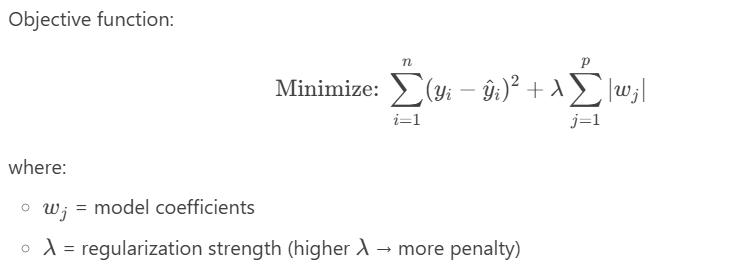

In [ ]:
from sklearn.linear_model import Lasso, LassoCV

l = Lasso(alpha = 0.01)
l.fit(X = df[['TV', 'Radio', 'Newspaper']], y = df['Sales'])
result = l.predict(X = df[['TV', 'Radio', 'Newspaper']])

result

array([21.21988714, 11.26753731, 10.49498336, 17.31141367, 15.64427526,
       10.35493494, 11.27306743, 13.27100938,  5.31968181, 15.78958343,
        8.85354515, 18.88422657,  9.69802776, 10.75013829, 19.27268511,
       20.38428896, 12.26963812, 24.20110148, 10.59275455, 15.20883509,
       19.49744351, 18.10486399,  7.06195675, 18.87244242,  9.37208414,
       19.32077436, 15.54476576, 19.4924308 , 21.07850728, 10.19494066,
       23.61446327, 12.6469957 , 10.08872592, 21.22642684,  9.98903742,
       20.89495588, 23.84442567, 13.99228596,  9.8403513 , 21.08279967,
       18.04710815, 17.84834212, 23.57497936, 16.79820788,  8.75603792,
       16.57667665, 10.58071758, 22.13277488, 18.70257611,  9.53226106,
       15.84740753, 11.12078596, 20.88154978, 19.5288304 , 22.01485876,
       20.75898296,  8.04301103, 14.10096423, 21.42104258, 19.25645591,
        7.76017549, 23.43798395, 19.32194645, 13.38680631, 16.35158623,
        9.37825096,  8.9735064 , 13.76494757, 20.49676282, 21.13

In [209]:
lasso_cv_model = LassoCV(cv = 8, random_state = 42)
lasso_cv_model.fit(X = df[['TV', 'Radio', 'Newspaper']], y = df['Sales'])
result = lasso_cv_model.predict(X = df[['TV', 'Radio', 'Newspaper']])

result

array([21.15062622, 11.2142765 , 10.41282076, 17.2390912 , 15.67630573,
       10.26107021, 11.24855101, 13.2918807 ,  5.41313229, 15.86091316,
        8.92240516, 18.88537103,  9.6541799 , 10.81595542, 19.22992417,
       20.28827149, 12.20178348, 24.1261916 , 10.61200215, 15.21030929,
       19.469397  , 18.16400422,  7.0911632 , 18.89018577,  9.41940041,
       19.38495042, 15.52981984, 19.51108823, 21.06024127, 10.22249875,
       23.58224045, 12.66732166, 10.16846299, 21.23904839, 10.07655684,
       20.95859257, 23.77237202, 13.90139918,  9.83440466, 21.0260965 ,
       18.04612228, 17.80816232, 23.55821794, 16.84709772,  8.75222528,
       16.57700697, 10.62983513, 22.06632516, 18.71655643,  9.57638945,
       15.91264927, 11.18058048, 20.80926307, 19.43709361, 21.99192348,
       20.65447845,  8.03272603, 14.12045371, 21.32220707, 19.23697786,
        7.84411566, 23.35406589, 19.34342345, 13.37508223, 16.28509813,
        9.44223858,  8.98639058, 13.80268932, 20.48178231, 21.05

In [207]:
l.coef_

array([0.05444495, 0.10696206, 0.00032411])

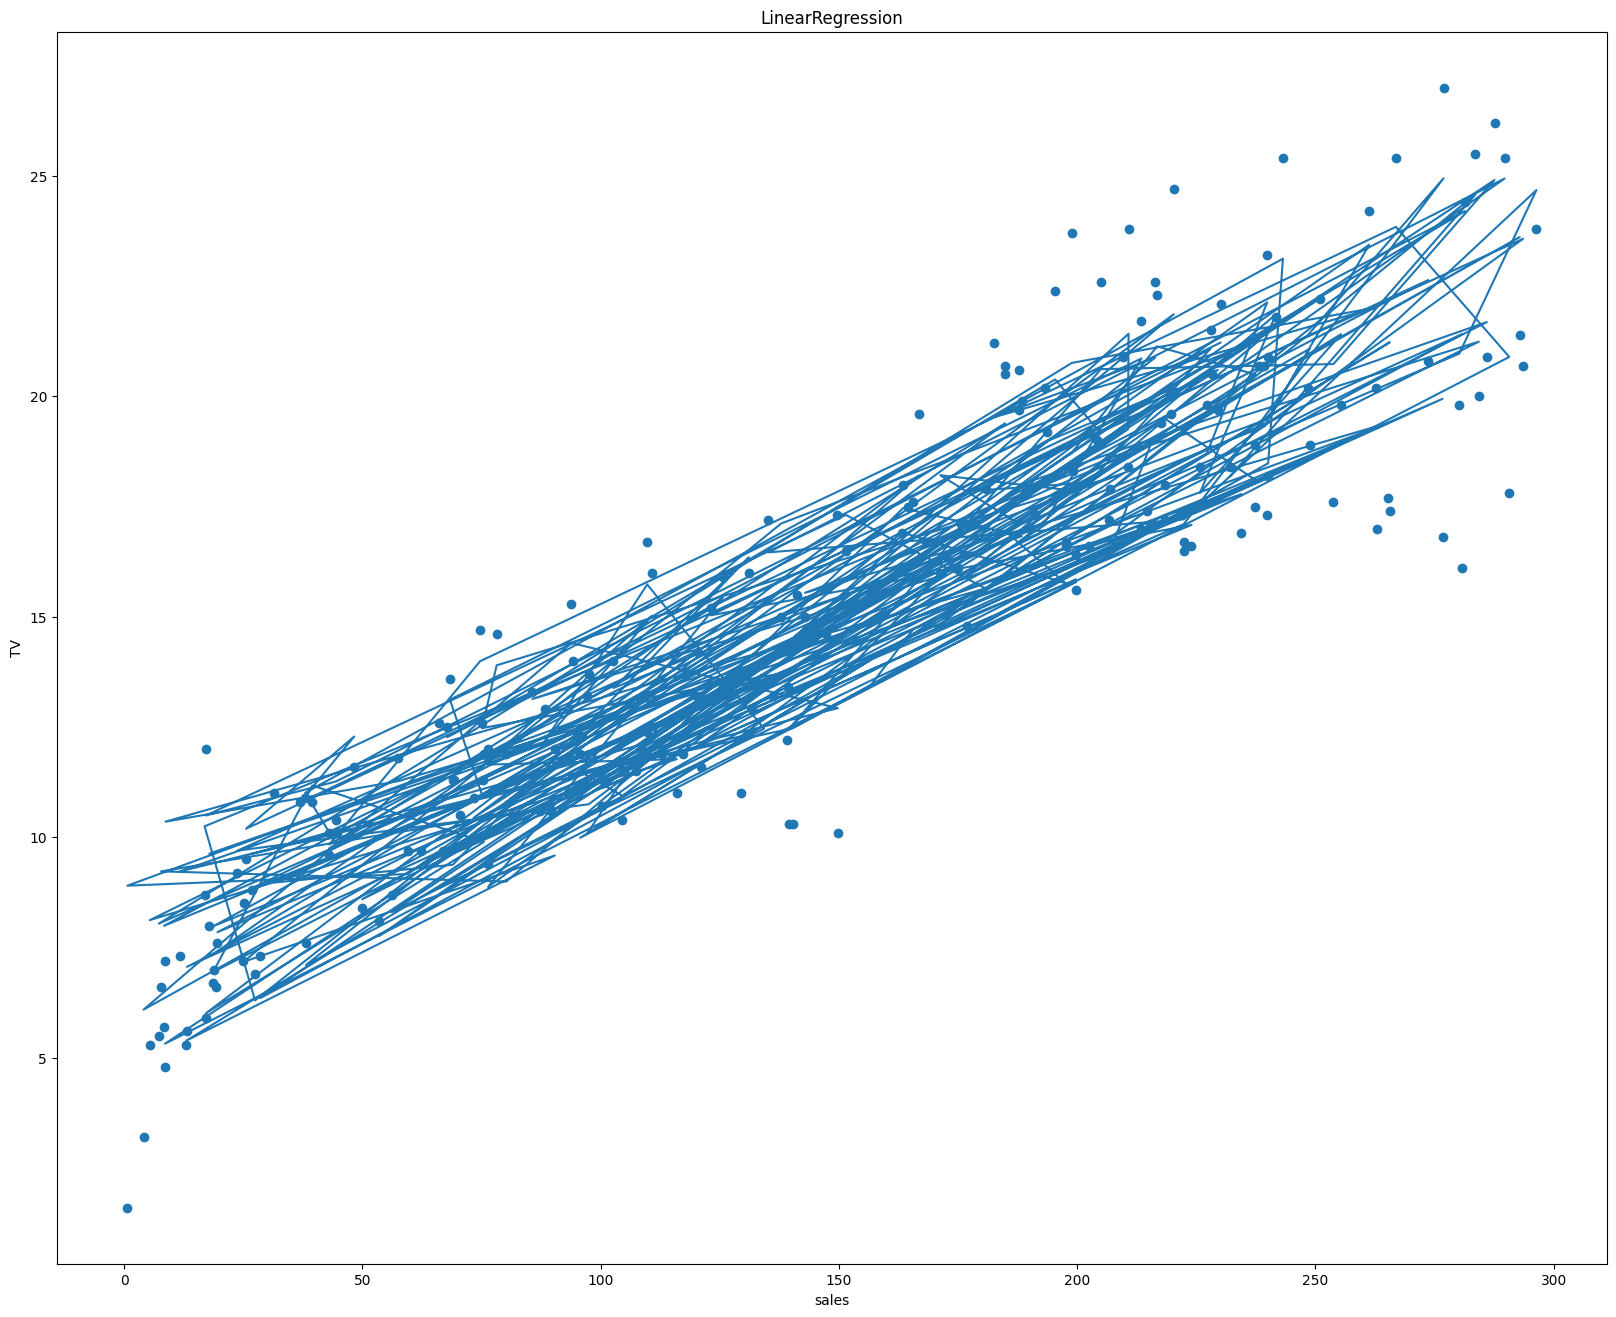

In [190]:
plt.figure(figsize=(20, 16))
plt.title('LinearRegression')
plt.scatter(x = df['TV'], y = df['Sales'])
plt.plot(df['TV'], result)
plt.xlabel(xlabel='sales')
plt.ylabel(ylabel='TV')
plt.show()

In [210]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mean_absolute_error(y_true=df['Sales'], y_pred=result)

1.2420208360477996

In [211]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mean_squared_error(y_true=df['Sales'], y_pred=result)

2.7091409749081397

**Ridge regression**

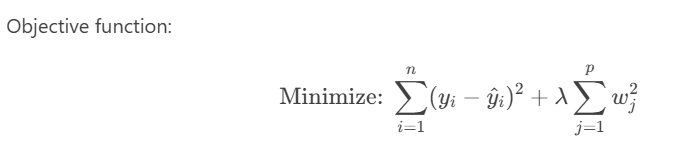

In [197]:
from sklearn.linear_model import Ridge

R = Ridge(alpha=0.001)
R.fit(X = df[['TV', 'Radio', 'Newspaper']], y = df['Sales'])
result = R.predict(X = df[['TV', 'Radio', 'Newspaper']])

result

array([21.22097207, 11.26824771, 10.49620894, 17.31244648, 15.6441369 ,
       10.35633673, 11.27328467, 13.27062458,  5.31839607, 15.78871018,
        8.85272025, 18.88400521,  9.69879661, 10.74921376, 19.2732885 ,
       20.38554439, 12.27105796, 24.20214498, 10.5924398 , 15.20872793,
       19.49794066, 18.1041466 ,  7.06177658, 18.87221074,  9.37145423,
       19.3199694 , 15.54479134, 19.49216303, 21.07865406, 10.19471069,
       23.61492831, 12.64683047, 10.08782557, 21.22604858,  9.98787089,
       20.89407059, 23.84503486, 13.99342405,  9.84045159, 21.08344931,
       18.04712878, 17.84885816, 23.57494336, 16.79762775,  8.75617872,
       16.57668108, 10.58020576, 22.13342736, 18.70257414,  9.5318134 ,
       15.84670862, 11.11990061, 20.88243417, 19.53008339, 22.01500288,
       20.76038988,  8.04320902, 14.10063487, 21.42220973, 19.25650781,
        7.75915892, 23.43911937, 19.32168183, 13.38676157, 16.35231891,
        9.37729646,  8.9731348 , 13.76436281, 20.49677832, 21.13

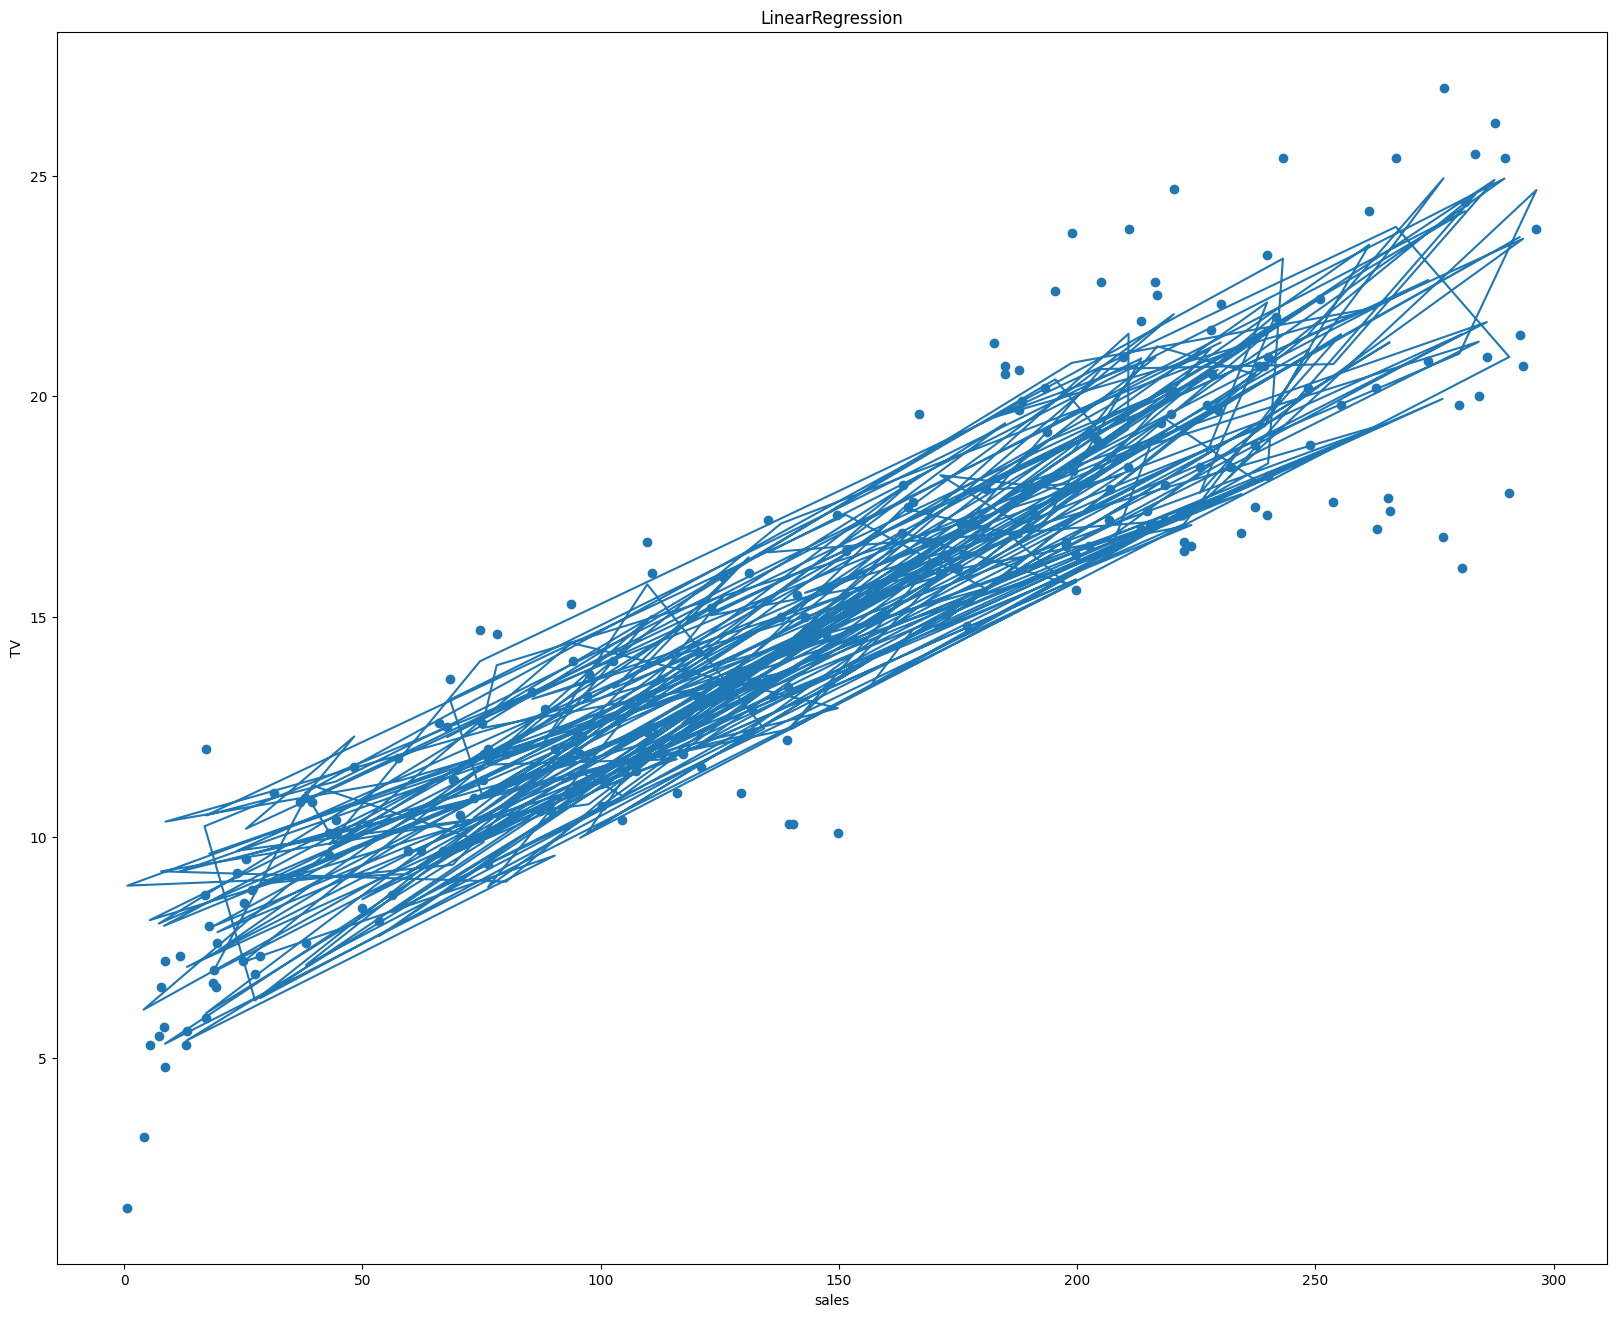

In [198]:
plt.figure(figsize=(20, 16))
plt.title('LinearRegression')
plt.scatter(x=df['TV'], y=df['Sales'])
plt.plot(df['TV'], result)
plt.xlabel(xlabel='sales')
plt.ylabel(ylabel='TV')
plt.show()

In [199]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mean_absolute_error(y_true=df['Sales'], y_pred=result)

1.236391996361463

In [200]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mean_squared_error(y_true=df['Sales'], y_pred=result)

2.706006147627317

In [ ]:
l

**Elastic Net(Combination of L1 and L2)**

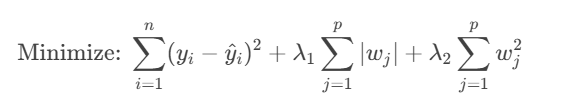

In [208]:
from sklearn.linear_model import ElasticNet, LassoCV

EN = ElasticNet(alpha = 1, l1_ratio = 0.5)
EN.fit(X = df[['TV', 'Radio', 'Newspaper']], y = df['Sales'])
result = EN.predict(X = df[['TV', 'Radio', 'Newspaper']])

result

array([21.17040017, 11.23061699, 10.43630673, 17.2608467 , 15.66230984,
       10.28791433, 11.25746281, 13.28672989,  5.38384827, 15.83761898,
        8.8991794 , 18.88816106,  9.66489993, 10.79577354, 19.24308877,
       20.31893985, 12.21554284, 24.14957044, 10.6064929 , 15.21107928,
       19.47672859, 18.14476819,  7.07855863, 18.88484446,  9.40422249,
       19.36451447, 15.53694179, 19.50583973, 21.06771033, 10.2116323 ,
       23.59239187, 12.65932668, 10.14095718, 21.23847633, 10.04888882,
       20.9396599 , 23.80037897, 13.93070357,  9.83559501, 21.04569132,
       18.04652963, 17.82116256, 23.56766954, 16.83095941,  8.75170893,
       16.57688172, 10.61219166, 22.09081265, 18.70986493,  9.56026187,
       15.88995473, 11.16287889, 20.8333279 , 19.46560223, 22.00182314,
       20.68728423,  8.03458609, 14.11527426, 21.35558817, 19.24625104,
        7.81597751, 23.38059579, 19.33671328, 13.38143065, 16.30807741,
        9.42329199,  8.98473547, 13.79196074, 20.48940969, 21.08

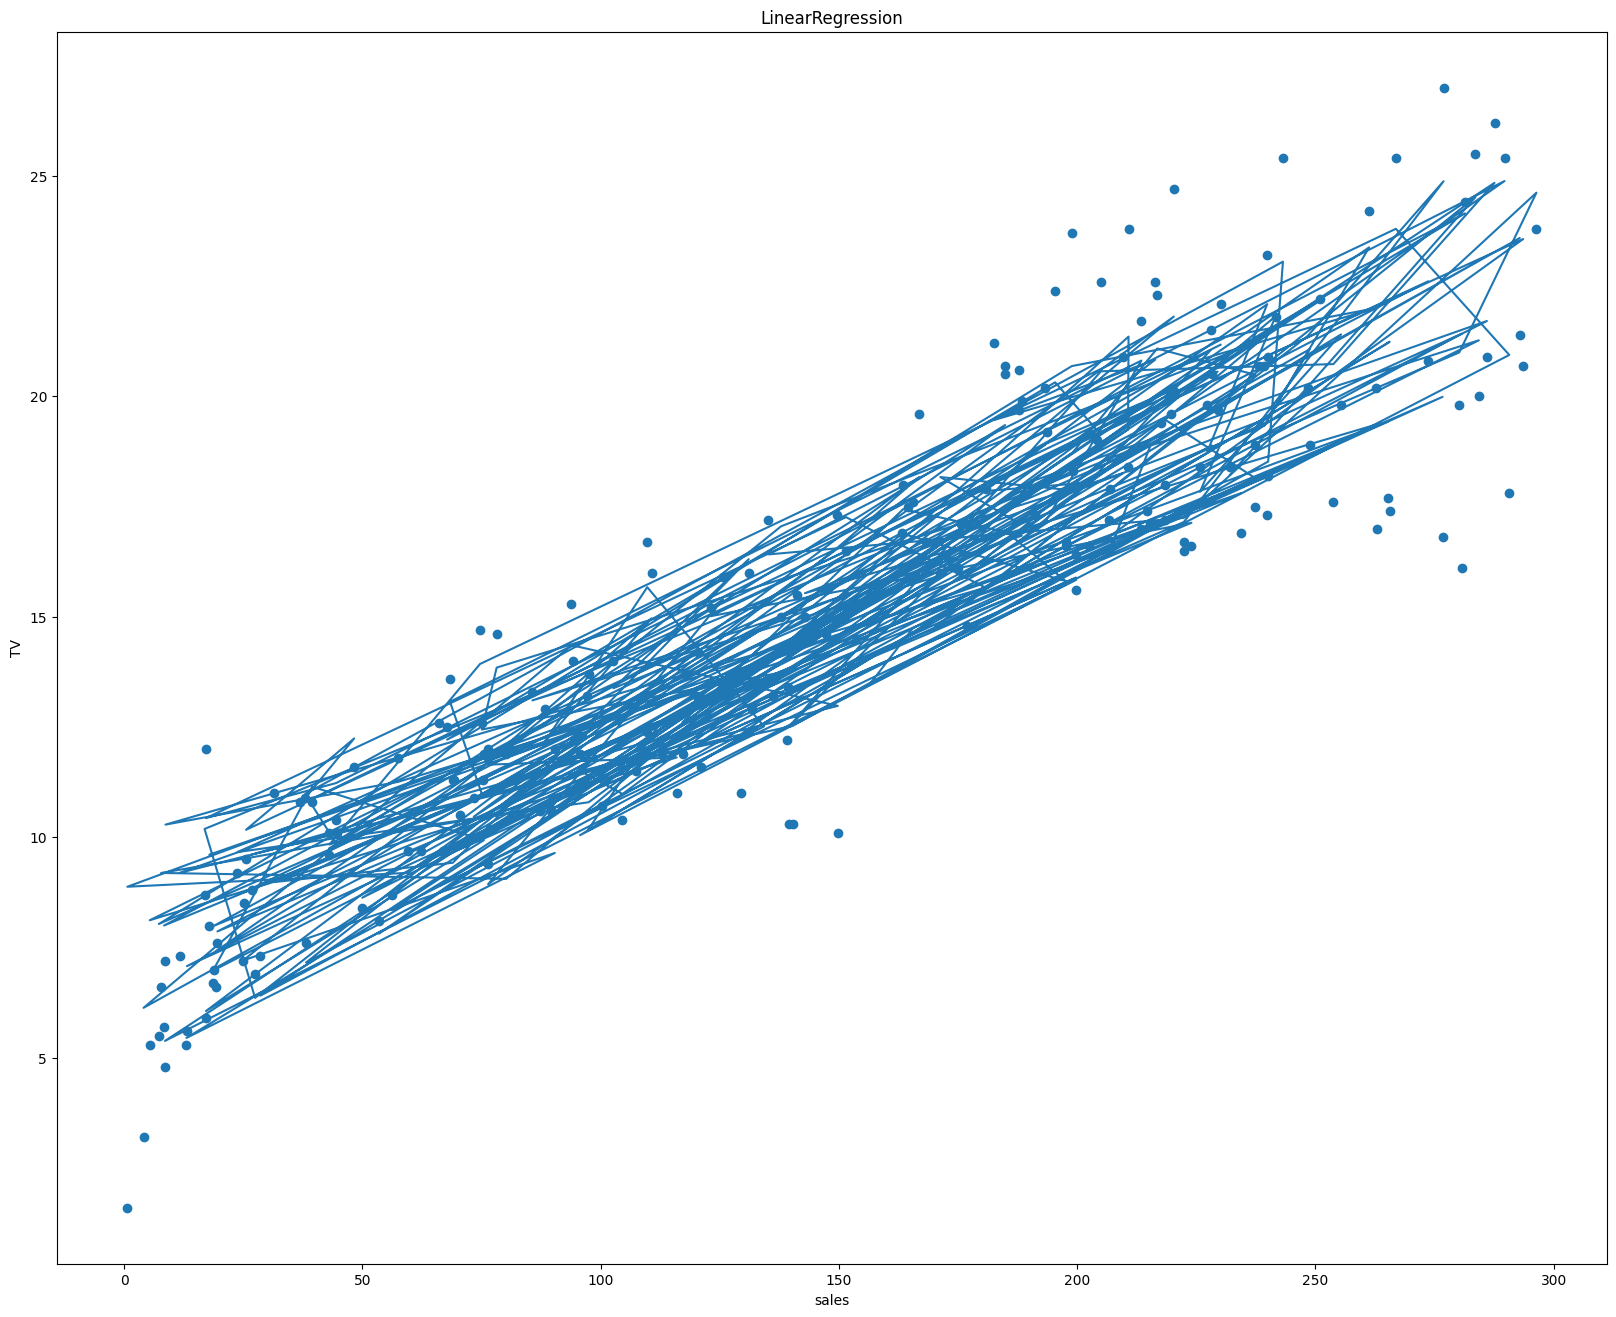

In [202]:
plt.figure(figsize=(20, 16))
plt.title('LinearRegression')
plt.scatter(x=df['TV'], y=df['Sales'])
plt.plot(df['TV'], result)
plt.xlabel(xlabel='sales')
plt.ylabel(ylabel='TV')
plt.show()

In [203]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mean_absolute_error(y_true=df['Sales'], y_pred=result)

1.2401047375878629

In [204]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mean_squared_error(y_true=df['Sales'], y_pred=result)

2.7074604979673187

In [205]:
R.intercept_

np.float64(4.625124125984815)

In [206]:
R.coef_

array([0.05444578, 0.10700123, 0.00033566])